In [92]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib import pyplot as plt
import seaborn as sns

In [93]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [94]:
# columns_to_drop = ['item_size']
# df = df.drop(columns=columns_to_drop)

In [95]:
df[df['shipment_classified']== '']

,quantity_in,bill_date,shipped_date,due_date,eta,seal,customs_broker,yield_percentage,shipment_classified


In [96]:
df.columns

Index(['quantity_in', 'bill_date', 'shipped_date', 'due_date', 'eta', 'seal',
       'customs_broker', 'yield_percentage', 'shipment_classified'],
      dtype='object')

In [97]:
# df['payment_terms'] = df['payment_terms'].astype(str).str.lower().str.strip()

In [ ]:
# --- 1️⃣ Copy dataframe ---
df_encoded = df.copy()


# --- 3️⃣ Encode target column ---
df_encoded["shipment_classified"] = df_encoded["shipment_classified"].map(
    {"on_time": 0, "delayed": 1}
)

# --- 4️⃣ Convert date columns ---
date_columns = [
    "eta",
    "due_date",
    "bill_date",
    "shipped_date",
]  # 'receipt_date' will only be placed after shipment is received
for col in date_columns:
    df_encoded[col] = pd.to_datetime(df_encoded[col], errors="coerce")


# for col in date_columns: 
#     df_encoded[f'{col}_month'] = df_encoded[f'{col}'].dt.month 
#     df_encoded[f'{col}_month'] = df_encoded[f'{col}_month'].astype('str') 
#     df_encoded[f'{col}_weekday'] = df_encoded[f'{col}'].dt.weekday 
#     df_encoded[f'{col}_weekday'] = df_encoded[f'{col}_weekday'].astype('str')



# df_encoded["eta_weekday"] = df_encoded["eta"].dt.weekday

# df_encoded["gap_between_due_and_eta"] = (df_encoded["due_date"] - df_encoded["eta"]).dt.days
# df_encoded["gap_between_shipped_and_due"] = (df_encoded["due_date"] - df_encoded["shipped_date"]).dt.days


df_encoded["gap_between_bill_and_shipment"] = (
    df_encoded["bill_date"] - df_encoded["shipped_date"]
).dt.days
df_encoded["gap_between_eta_shipped"] = (
    df_encoded["eta"] - df_encoded["shipped_date"]
).dt.days
df_encoded["gap_between_eta_bill"] = (
    df_encoded["eta"] - df_encoded["bill_date"]
).dt.days

df_encoded["due_gap"] = (
    pd.to_datetime(df_encoded["due_date"]) - pd.to_datetime(df_encoded["bill_date"])
).dt.days
# df_encoded["responsiveness"] = (
#     df_encoded["bill_date"] - df_encoded["shipped_date"]
# ).dt.days

df_encoded["broker_frequency"] = df_encoded["customs_broker"].map(
    df_encoded["customs_broker"].value_counts()
)


# ['gap_between_due_and_eta', 'gap_between_shipped_and_due', 'responsiveness']
# --- 5️⃣ Identify and drop highly correlated features ---
def drop_highly_correlated_features(data, threshold=0.9):
    corr_matrix = data.corr().abs()
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop = [
        column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)
    ]
    print(f"\nHighly correlated features (>|{threshold}|) to drop:\n{to_drop}")
    return data.drop(columns=to_drop, errors="ignore")

numerical_cols = df_encoded.select_dtypes(include=[np.number]).columns
df_encoded = drop_highly_correlated_features(df_encoded[numerical_cols])


# df_encoded.drop(["customs_broker"] + date_columns, axis=1, inplace=True)


# --- 8️⃣ Handle categorical columns ---
# categorical_cols = ["seal"]
# from sklearn.preprocessing import LabelEncoder

# for col in categorical_cols:
#     if df_encoded[col].nunique() > 100:
#         le = LabelEncoder()
#         df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))


# X, y split for training
X = df_encoded.drop("shipment_classified", axis=1)
y = df_encoded["shipment_classified"]


Highly correlated features (>|0.9|) to drop:
[]


In [117]:
X.columns

Index(['quantity_in', 'yield_percentage', 'gap_between_bill_and_shipment',
       'gap_between_eta_shipped', 'gap_between_eta_bill', 'due_gap',
       'broker_frequency'],
      dtype='object')

In [99]:
df_encoded.isna().sum()[df_encoded.isna().sum() > 0]

Series([], dtype: int64)

In [100]:
# df['opening_stock'].describe()

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 820 entries, 0 to 819
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   quantity_in          820 non-null    float64
 1   bill_date            820 non-null    object 
 2   shipped_date         820 non-null    object 
 3   due_date             820 non-null    object 
 4   eta                  820 non-null    object 
 5   seal                 820 non-null    object 
 6   customs_broker       820 non-null    object 
 7   yield_percentage     820 non-null    float64
 8   shipment_classified  820 non-null    object 
dtypes: float64(2), object(7)
memory usage: 57.8+ KB


In [102]:
# Step 2: Data preprocessing
# df['inventory'] = df['inventory'].map({'Yes': 1, 'No': 0})
# df['shipment_classified'] = df['shipment_classified'].map({'on_time': 0, 'delayed': 1})

In [103]:
# Encode categorical columns
# cat_cols = df.select_dtypes(include=['object']).columns
# le = LabelEncoder()
# for col in cat_cols:
#     df[col] = le.fit_transform(df[col])

In [104]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 820 entries, 0 to 819
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   quantity_in                    820 non-null    float64
 1   yield_percentage               820 non-null    float64
 2   shipment_classified            820 non-null    int64  
 3   gap_between_bill_and_shipment  820 non-null    int64  
 4   gap_between_eta_shipped        820 non-null    int64  
 5   gap_between_eta_bill           820 non-null    int64  
 6   due_gap                        820 non-null    int64  
 7   broker_frequency               820 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 51.4 KB


In [105]:
# # Step 3: Split features & target
# X = df.drop('shipment_classified', axis=1)
# y = df['shipment_classified']

In [106]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [107]:
df_encoded

,quantity_in,yield_percentage,shipment_classified,gap_between_bill_and_shipment,gap_between_eta_shipped,gap_between_eta_bill,due_gap,broker_frequency
0,35000.0,99.0,1,21,14,-7,0,5
1,29892.0,0.0,0,53,49,-4,30,16
2,4452.0,0.0,0,53,49,-4,30,16
3,34020.0,79.0,0,70,66,-4,0,222
4,35280.0,105.0,0,60,55,-5,0,41
...,...,...,...,...,...,...,...,...
815,36000.0,0.0,0,37,35,-2,10,222
816,36000.0,0.0,0,38,35,-3,10,222
817,36000.0,0.0,0,37,35,-2,10,222
818,36000.0,0.0,0,37,35,-2,10,222


In [108]:
# Step 5: Scale features
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [109]:
# Step 6: Train model
model = LogisticRegression(class_weight = "balanced", max_iter=1000, penalty='l1', solver='liblinear')
model.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [110]:
print(model.classes_)

[0 1]


In [111]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi = mutual_info_classif(X, y)
pd.Series(mi, index=X.columns).sort_values(ascending=False)

gap_between_eta_bill             0.423320
gap_between_eta_shipped          0.072842
gap_between_bill_and_shipment    0.028447
yield_percentage                 0.016834
due_gap                          0.009349
broker_frequency                 0.001445
quantity_in                      0.000000
dtype: float64

In [112]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)
from sklearn.metrics import make_scorer, f1_score

from sklearn.model_selection import cross_validate

results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

print("Mean Accuracy:", round(results['test_accuracy'].mean(),2))
print("Mean Precision:", round(results['test_precision'].mean(),2))
print("Mean Recall:", round(results['test_recall'].mean(),2))
print("Mean F1:", round(results['test_f1'].mean(),2))



Mean Accuracy: 1.0
Mean Precision: 1.0
Mean Recall: 1.0
Mean F1: 1.0


In [113]:
# Step 7: Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[139   0]
 [  0  25]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       139
           1       1.00      1.00      1.00        25

    accuracy                           1.00       164
   macro avg       1.00      1.00      1.00       164
weighted avg       1.00      1.00      1.00       164



In [114]:
# Optional: Feature importance
importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
print("\nTop features influencing delay:\n", importance.head(10))



Top features influencing delay:
 gap_between_bill_and_shipment    0.000000
quantity_in                     -0.000051
broker_frequency                -0.000380
yield_percentage                -0.004434
due_gap                         -0.005162
gap_between_eta_shipped         -0.066138
gap_between_eta_bill            -5.398768
dtype: float64


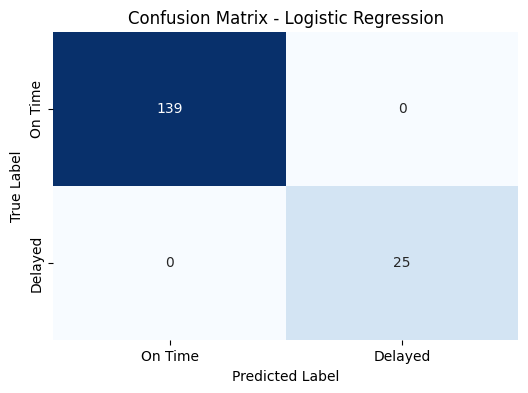

In [115]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

/Users/prashant/.pyenv/versions/ideabox-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


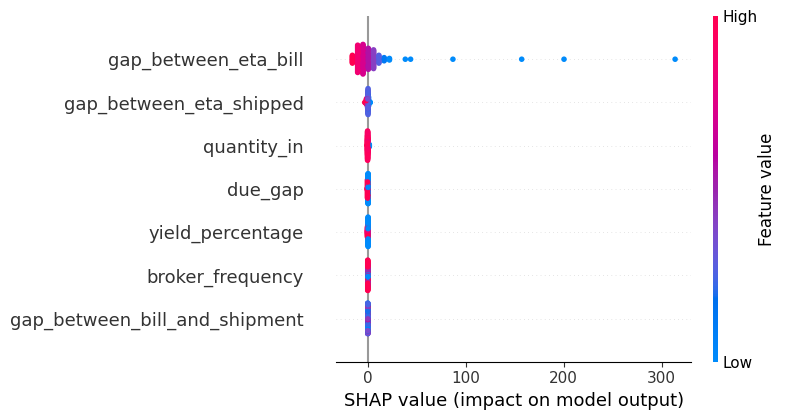

In [116]:
import shap
explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)


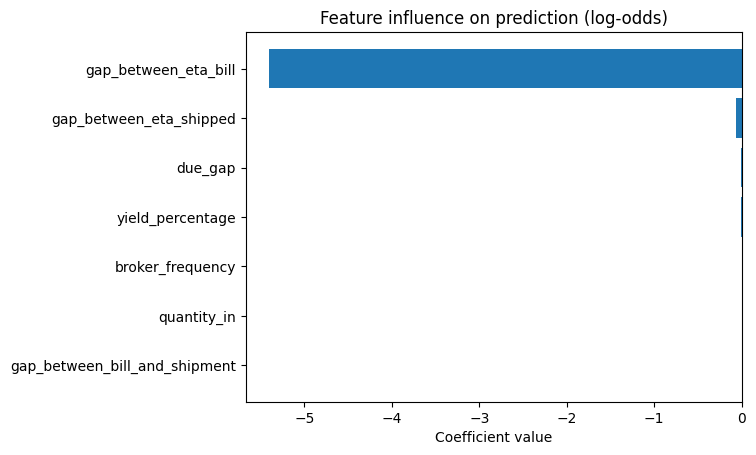

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.title("Feature influence on prediction (log-odds)")
plt.xlabel("Coefficient value")
plt.show()


In [ ]:
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

In [120]:
coef_df

,feature,coefficient,odds_ratio
2,gap_between_bill_and_shipment,0.000000,1.000000
0,quantity_in,-0.000051,0.999949
6,broker_frequency,-0.000380,0.999620
1,yield_percentage,-0.004434,0.995576
5,due_gap,-0.005162,0.994851
3,gap_between_eta_shipped,-0.066138,0.936002
4,gap_between_eta_bill,-5.398768,0.004522


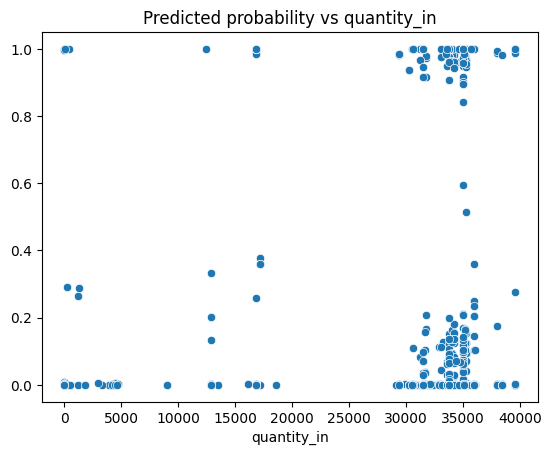

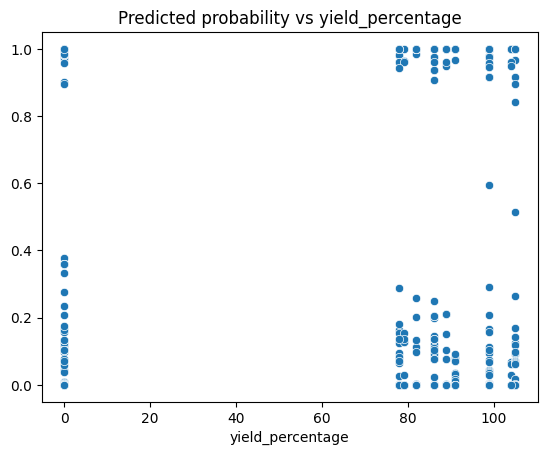

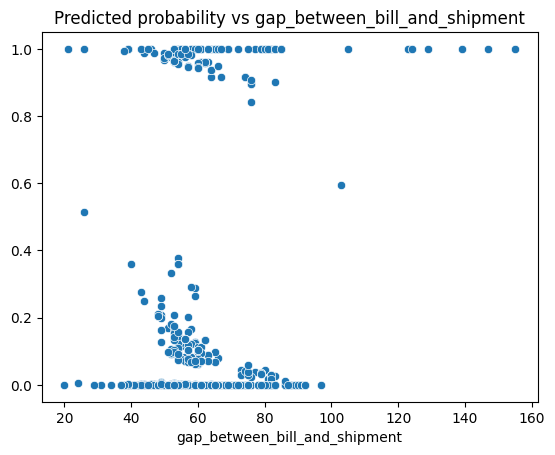

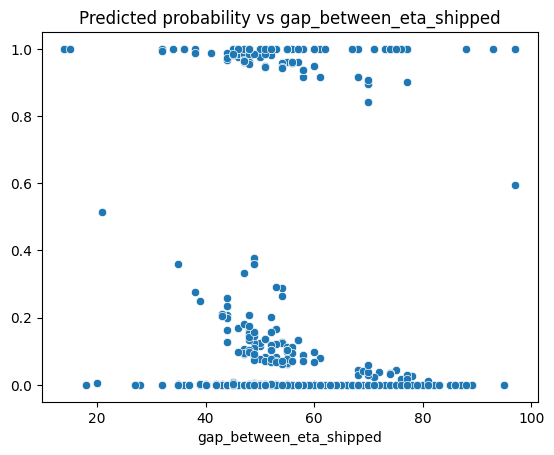

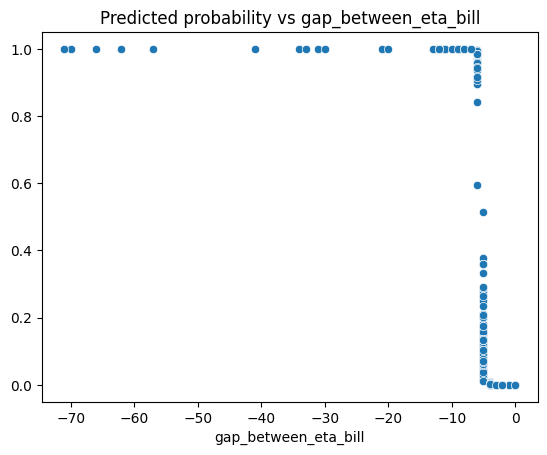

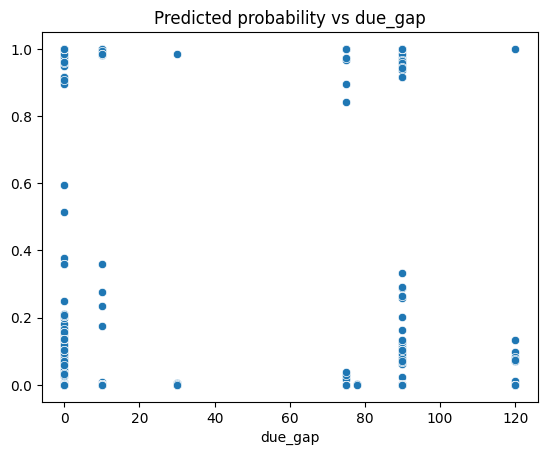

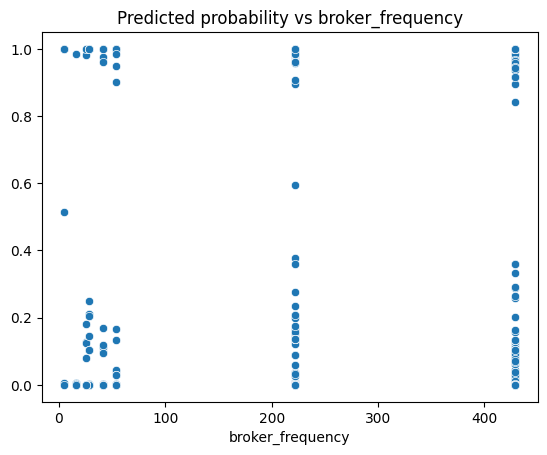

In [121]:
import seaborn as sns

for f in X.columns:
    sns.scatterplot(x=X[f], y=model.predict_proba(X)[:,1])
    plt.title(f"Predicted probability vs {f}")
    plt.show()


In [122]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(X_train.values, feature_names=X.columns,
                                 class_names=['class0','class1'], discretize_continuous=True)
exp = explainer.explain_instance(X_test.iloc[0].values, model.predict_proba)
exp.show_in_notebook(show_table=True)


/Users/prashant/.pyenv/versions/ideabox-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
